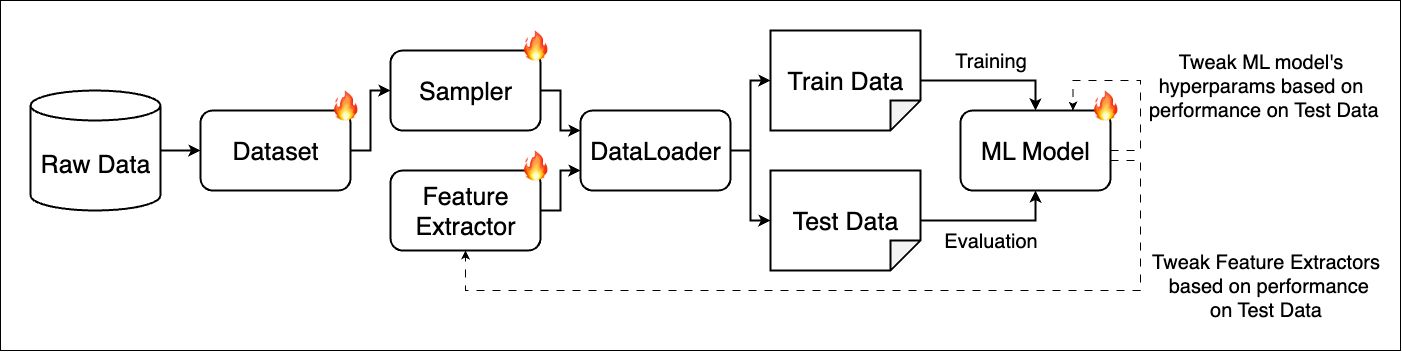

# Assignment 1
## ✅ Rename the filename with your roll number. E.g. if your roll number is `MT24003` then rename the file `MT24003_a1.ipynb` before submitting.
## ✅ Write code only in the sections marked with `# YOUR CODE HERE`. No, you can NOT write code anywhere else.
## ✅ Download and extract the `data.zip` folder next to this file. If you extract it correctly, you will have a `data` folder next to this file.
## ❌ Do not modify any other function or class definitions; doing so may lead to the autograder failing to judge your submission, resulting in a zero.
## ❌ Deleting or adding new cells may lead to the `autograder` failing to judge your submission, resulting in a zero. Even if a cell is empty, do NOT delete it.
## ❌ Do NOT install / import any other libraries. You should be able to solve all the questions using only the libraries imported below.


In [2]:
import os
import json
import glob
import random
from typing import Dict, List, Any, Tuple, Optional
from abc import ABC, abstractmethod

import numpy as np
from PIL import Image
import librosa
import scipy
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
import librosa

PATH_TO_DATA_DIR = "./MLA2_DATA"
PATH_TO_TRAIN_DIR = os.path.join(PATH_TO_DATA_DIR, "TRAIN")
PATH_TO_TEST_DIR = os.path.join(PATH_TO_DATA_DIR, "TEST")

PATH_TO_IMAGE_TRAIN_DIR = os.path.join(PATH_TO_TRAIN_DIR, "IMAGE")
PATH_TO_AUDIO_TRAIN_DIR = os.path.join(PATH_TO_TRAIN_DIR, "AUDIO")
PATH_TO_TEXT_TRAIN_DIR = os.path.join(PATH_TO_TRAIN_DIR, "TEXT")

PATH_TO_IMAGE_TEST_DIR = os.path.join(PATH_TO_TEST_DIR, "IMAGE")
PATH_TO_AUDIO_TEST_DIR = os.path.join(PATH_TO_TEST_DIR, "AUDIO")
PATH_TO_TEXT_TEST_DIR = os.path.join(PATH_TO_TEST_DIR, "TEXT")

# `q1` Data Loading and Preprocessing

1. Populate the functions in all the Dataset classes in the following code cell only where the `### YOUR CODE HERE` marker is present.
2. Follow the instructions in the doc strings of the functions to implement the functions.
3. Grading [total: 1.5]
   1. `ImageDataset` class compiles and passes hidden tests with no errors: 0.5
   2. `AudioDataset` class compiles and passes hidden tests with no errors: 0.5
   3. `TextDataset` class compiles and passes hidden tests with no errors: 0.5

In [3]:
############################
# Q1: Datasets
############################


class BaseDataset(ABC):
    """
    Shared interface for modality-specific datasets.

    Attributes
    - modality: string describing modality ("image" | "audio" | "text"). Set by subclasses.
    """

    def __init__(self, data_dir: str):
        self.data_dir: str = data_dir
        self.modality: str = ""

    @abstractmethod
    def __len__(self) -> int:
        ...

    @abstractmethod
    def __getitem__(self, idx: int) -> Dict[str, Any]:
        ...


class ImageDataset(BaseDataset):
    """
    Load images organized under per-class folders.
    """

    def __init__(self, path_to_image_data_dir: str = PATH_TO_IMAGE_TRAIN_DIR):
        super().__init__(path_to_image_data_dir)
        self.modality = "image"
        self.records = []

        ### YOUR CODE HERE
        class_labels = [f for f in os.listdir(self.data_dir) if os.path.isdir(os.path.join(self.data_dir, f))]
        
        for label in class_labels:
            valid_extensions = (".jpg", ".jpeg")
            img_path = os.path.join(path_to_image_data_dir,label)
            images = [f for f in os.listdir(img_path) if f.lower().endswith(valid_extensions)]
            for image in images:
                record = {
                    "path":os.path.join(img_path,image),
                    "class":label,
                    }
                self.records.append(record)

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        record = {
            "class": None,
        }
        ### YOUR CODE HERE
        image_path = self.records[idx]["path"]
        image_label = self.records[idx]["class"]
        image = Image.open(image_path).convert("RGB")
        record = {
            "class" : image_label,
            "image" : np.array(image),
            "image_grayscale" : np.array(Image.open(image_path).convert("L")),
            "path" : image_path,
        }
        return record

class AudioDataset(BaseDataset):
    """
    Load WAV files and metadata.
    """

    def __init__(self, path_to_audio_data_dir: str = PATH_TO_AUDIO_TRAIN_DIR):
        super().__init__(path_to_audio_data_dir)
        self.modality = "audio"
        self.records = []

        ### YOUR CODE HERE
        audio_files = [f for f in os.listdir(self.data_dir) if f.lower().endswith(".wav")]

        for audio_file in audio_files:
            label = audio_file.split("_")[-1][:-4] # files are named like "x$$$$_$_classlabel.wav"
            record = {
                "class": label,
                "path": os.path.join(self.data_dir, audio_file),
            }
            self.records.append(record)
            

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        record = {
            "class": None,
        }
        ### YOUR CODE HERE
        audio_path = self.records[idx]["path"]
        audio_label = self.records[idx]["class"]
        
        y, sr = librosa.load(audio_path, sr=None)
        rms = librosa.feature.rms(y=y)[0]

        record = {
            "path": audio_path,
            "class": audio_label,
            "audio": y,
            "sr": sr,
            "rms": rms,
        }
        return record

class TextDataset(BaseDataset):
    """
    Load text data.
    """

    def __init__(self, path_to_text_data_dir: str = PATH_TO_TEXT_TRAIN_DIR):
        super().__init__(path_to_text_data_dir)
        self.modality = "text"
        self.records = []

        ### YOUR CODE HERE
        jsonl_file = [f for f in os.listdir(self.data_dir) if f.lower().endswith(".jsonl")][0]

        with open(os.path.join(self.data_dir,jsonl_file),'r') as jsonl_file:
            for data in jsonl_file:
                if data.strip():
                    record = json.loads(data)
                    self.records.append(record)

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        record = {
            "class": None,
        }
        ### YOUR CODE HERE
        record = self.records[idx].copy()
        record["class"] = record["label"]
        return record


    def get_corpus(self) -> List[str]:
        """
        [OPTIONAL]
        Return the full collection of text strings in the dataset.

        Requirement:
        - This function is optional and you may leave the code untouched if you do not want to use it.
        - Extract and return the raw text for each stored record.
        - Suggested use case: you can use this function to build tf-idf vectorizer later in the `get_text_features` function.
        """
        corpus = []
        ### YOUR CODE HERE
        for record in self.records:
            corpa = record["norm"] + record["situation"] + record["intention"]
            if "moral_action" in record:
                corpa += record["moral_action"] + record["moral_consequence"]
            else:
                corpa += record["immoral_action"] + record["immoral_consequence"]

            corpus.append(corpa)
        return corpus

In [4]:
img_ds = ImageDataset()
print(f"[Q1] ImageDataset -> modality={img_ds.modality}, num_samples={len(img_ds)}")

audio_ds = AudioDataset() 
print(f"[Q1] AudioDataset -> modality={audio_ds.modality}, num_samples={len(audio_ds)}")

text_ds = TextDataset()
print(f"[Q1] TextDataset -> modality={text_ds.modality}, num_samples={len(text_ds)}")


[Q1] ImageDataset -> modality=image, num_samples=6168
[Q1] AudioDataset -> modality=audio, num_samples=10871
[Q1] TextDataset -> modality=text, num_samples=20000


# `q2` Samplers and DataLoader

1. Populate the functions in the all the `Sampler` classes in the following code cell only where the `### YOUR CODE HERE` marker is present.
2. Follow the instructions in the doc strings of the functions to implement the functions.
3. Grading [total: 1.5]
   1. `RandomSampler` class compiles and passes hidden tests with no errors: 0.5
   2. `WeightedRandomSampler` class compiles and passes hidden tests with no errors: 1.0

In [ ]:
############################
# Q2: Samplers and DataLoader
############################


from matplotlib.pyplot import gray


class BaseSampler(ABC):
    """Common interface for samplers"""

    @abstractmethod
    def sample_indices(self, dataset: BaseDataset, num_samples: Optional[int] = None) -> List[int]:
        ...


class RandomSampler(BaseSampler):
    """Uniform random sampler.

    Requirement:
    - Probability of each record being sampled is uniform.
    - Sampling is without replacement.
    - Works for any dataset modality.
    """

    def __init__(self, dataset: BaseDataset) -> None:
        """
        Initialize the uniform sampler.

        Requirement:
        - No precomputation is required; may store references if needed.
        """
        ### YOUR CODE HERE
        self.dataset = dataset
        self.num_records = len(dataset)

    def sample_indices(self, dataset: BaseDataset, num_samples: Optional[int] = None) -> List[int]:
        """
        Draw indices uniformly at random without replacement.

        Requirement:
        - Every record has equal probability.
        - Respect `num_samples`; if None, select all records.
        - Return a list of unique indices.
        """
        ### YOUR CODE HERE
        if num_samples : 
            num_samples = min(num_samples,self.num_records)
            return random.sample(range(self.num_records),num_samples)
        else: return random.sample(range(self.num_records),self.num_records)

class WeightedRandomSampler(BaseSampler):
    """Weighted random sampler favoring least-similar classes.

    Requirement:
    - Derive class similarity internally (no external information):
      - Image: cosine similarity of grayscale histograms.
      - Audio: cosine similarity of loudness vectors.
      - Text: cosine similarity of tokenized sentence vectors.
    - Convert similarity to weights that prefer less-similar classes (inverse similarity).
    - This mapping from class to weight should be stored in the `class_weights` attribute.
    - Sampling is weighted by inverse similarity, so rare/dissimilar classes are sampled more frequently
      to ensure balanced representation in the final sample.
    """

    def __init__(self, dataset: BaseDataset) -> None:
        """
        Initialize and compute class weights from dataset-internal representations.

        Requirement:
        - Build a per-class representation per modality and compute pairwise cosine similarities.
        - Convert similarities into class-selection weights that emphasize dissimilar classes.
        - Do not use any external/precomputed similarity information.
        """
        self.class_weights = {}
        ### YOUR CODE HERE
        self.dataset = dataset
        self.num_records = len(dataset)

        labels = []
        for i in range(self.num_records):
            record = dataset[i]
            if record["class"] not in labels : labels.append(record["class"])
        
        class_to_indices = {}
        for label in labels : class_to_indices[label] = []

        for i in range(self.num_records):
            class_to_indices[dataset[i]["class"]].append(i)

        sample_record = dataset[0]
        if "image" in sample_record:
            self.dataset_modality = "image"
        elif "audio" in sample_record:
            self.dataset_modality = "audio"
        else:
            self.dataset_modality = "text"

        if self.dataset_modality == "image":

            feature_vector_per_class = {}

            for img_class in class_to_indices:
                histograms = []

                for img_idx in class_to_indices[img_class]:
                    image = dataset[img_idx]
                    hist, _ = np.histogram(image["image_grayscale"].ravel(), bins=64, range=(0, 256), density=True)
                    histograms.append(hist)
                
                vec = np.mean(histograms, axis=0)
                feature_vector_per_class[img_class] = vec / (np.linalg.norm(vec) + 1e-8)

            labels = list(feature_vector_per_class.keys())
            vectors = np.stack([feature_vector_per_class[l] for l in labels]) 

            S = sklearn.metrics.pairwise.cosine_similarity(vectors)
            sim_mean = S.mean(axis=1)

            eps = 1e-8
            raw_w = 1.0 / (sim_mean + eps)
            class_weights = raw_w / raw_w.sum()

            self.class_weights = dict(zip(labels, class_weights))
        elif self.dataset_modality == "audio":
            
            feature_vector_per_class = {}

            global_max_rms = max([rec["rms"].max() for rec in dataset])

            for audio_class in class_to_indices:
                histograms = []

                for audio_idx in class_to_indices[audio_class]:
                    loudness = dataset[audio_idx]["rms"]
                    hist, _ = np.histogram(loudness, bins = 64, range=(0,global_max_rms + 1e-8), density=True )
                    histograms.append(hist)

                vec = np.mean(histograms, axis=0)
                feature_vector_per_class[audio_class] = vec / (np.linalg.norm(vec) + 1e-8)
            
            labels = list(feature_vector_per_class.keys())
            vectors = np.stack([feature_vector_per_class[audio_class] for audio_class in labels])

            S = sklearn.metrics.pairwise.cosine_similarity(vectors)
            sim_mean = S.mean(axis = 1)

            eps = 1e-8
            raw_weights = 1.0 / (sim_mean + eps)
            class_weights = raw_weights/raw_weights.sum()

            self.class_weights = dict(zip(labels,class_weights))
        else:
            from sklearn.feature_extraction.text import TfidfVectorizer
            from sklearn.metrics.pairwise import cosine_similarity

            corpus = dataset.get_corpus()
            labels_per_record = [rec["class"] for rec in dataset]

            vectorizer = TfidfVectorizer()
            X = vectorizer.fit_transform(corpus)   # shape = (num_records, vocab_size)

            class_to_indices = {}
            for i, lbl in enumerate(labels_per_record):
                class_to_indices.setdefault(lbl, []).append(i)

            feature_vector_per_class = {}
            for lbl, idxs in class_to_indices.items():
                vecs = X[idxs].toarray()
                vec = np.mean(vecs, axis=0)
                vec = vec / (np.linalg.norm(vec) + 1e-8)
                feature_vector_per_class[lbl] = vec

            class_labels = list(feature_vector_per_class.keys())
            vectors = np.stack([feature_vector_per_class[l] for l in class_labels])

            S = cosine_similarity(vectors)
            sim_mean = S.mean(axis=1)
            raw_w = 1.0 / (sim_mean + 1e-8)
            class_weights = raw_w / raw_w.sum()

            self.class_weights = dict(zip(class_labels, class_weights))

        self._class_to_indices = class_to_indices


    def sample_indices(self, dataset: BaseDataset, num_samples: Optional[int] = None) -> List[int]:
        """
        Sample record indices by first selecting classes via inverse-similarity weights.

        Requirement:
        - Respect `num_samples`; if None, select all available records.
        - Choose classes according to computed weights, then sample records without replacement.
        - Return a list of unique indices, length ≤ `num_samples`.
        """
        num_samples = min(num_samples, len(dataset))
        ### YOUR CODE HERE
        num_samples = len(dataset) if num_samples is None else min(num_samples, len(dataset))

        labels = list(self.class_weights.keys())
        weights = np.array([self.class_weights[l] for l in labels])

        chosen_indices = []
        used = set()

        while len(chosen_indices) < num_samples:
            chosen_class = np.random.choice(labels, p=weights)

            idx = np.random.choice(self._class_to_indices[chosen_class])

            if idx not in used:
                chosen_indices.append(idx)
                used.add(idx)

        return chosen_indices

def get_image_features(sample: Dict[str, Any]) -> np.ndarray:
    """
    Get image features from a sample.
    
    Requirement:
    - Perform any type of feature engineering on the image as long as you do not import libraries that are not already imported. 
    - You must populate the `features` variable with the features of the image.
    """
    features = None
    ### YOUR CODE HERE
    from scipy import ndimage

    img = np.asarray(sample["image"]).astype(float)
    gray = np.asarray(sample["image_grayscale"]).astype(float)

    if img.ndim != 3 or img.shape[2] < 3:
        img = np.stack([gray, gray, gray], axis=-1)

    H, W = gray.shape[:2]
    eps = 1e-8

    def rgb_to_hsv(img_in):
        norm = img_in / 255.0
        r, g, b = norm[..., 0], norm[..., 1], norm[..., 2]
        cmax = np.maximum.reduce([r, g, b])
        cmin = np.minimum.reduce([r, g, b])
        delta = cmax - cmin

        h = np.zeros_like(cmax)
        mask = delta > 0
        r_eq = mask & (cmax == r)
        g_eq = mask & (cmax == g)
        b_eq = mask & (cmax == b)

        h[r_eq] = ( ( (g[r_eq] - b[r_eq]) / (delta[r_eq] + eps) ) % 6 ) * 60.0
        h[g_eq] = ( ( (b[g_eq] - r[g_eq]) / (delta[g_eq] + eps) ) + 2 ) * 60.0
        h[b_eq] = ( ( (r[b_eq] - g[b_eq]) / (delta[b_eq] + eps) ) + 4 ) * 60.0
        h = h / 360.0

        s = np.zeros_like(cmax)
        nonzero = cmax > 0
        s[nonzero] = delta[nonzero] / (cmax[nonzero] + eps)
        v = cmax
        return np.stack([h, s, v], axis=-1)

    def extract_base_features(rgb_img, gray_img, grid_size=4, hue_bins=8):
        hsv = rgb_to_hsv(rgb_img)
        blurred = ndimage.gaussian_filter(gray_img, sigma=0.7)
        gx = ndimage.sobel(blurred, axis=0)
        gy = ndimage.sobel(blurred, axis=1)
        edge_map = np.hypot(gx, gy)

        all_f = []
        ch = max(1, H // grid_size)
        cw = max(1, W // grid_size)
        for i in range(grid_size):
            for j in range(grid_size):
                y1 = i * ch
                x1 = j * cw
                y2 = min(H, (i + 1) * ch)
                x2 = min(W, (j + 1) * cw)

                cell_hsv = hsv[y1:y2, x1:x2]
                cell_gray = gray_img[y1:y2, x1:x2]
                cell_edge = edge_map[y1:y2, x1:x2]

                if cell_hsv.size == 0:
                    all_f.extend([0.0] * (hue_bins + 4))
                    continue

                hvals = cell_hsv[..., 0].ravel()
                hist, _ = np.histogram(hvals, bins=hue_bins, range=(0.0, 1.0), density=True)
                sat_mean = float(cell_hsv[..., 1].mean()) if cell_hsv[..., 1].size else 0.0
                val_mean = float(cell_hsv[..., 2].mean()) if cell_hsv[..., 2].size else 0.0
                edge_mean = float(cell_edge.mean()) if cell_edge.size else 0.0

                fft_mag = 0.0
                try:
                    f = np.fft.fft2(cell_gray)
                    f = np.abs(f)
                    fft_mag = float(f.ravel()[:3].sum()) if f.size >= 3 else float(f.sum())
                except Exception:
                    fft_mag = 0.0

                all_f.extend(hist.tolist())
                all_f.extend([sat_mean, val_mean, edge_mean, fft_mag])

        return np.array(all_f, dtype=float)

    def global_color_hist(rgb_img, bins_per_channel=8):
        parts = []
        for c in range(3):
            hist, _ = np.histogram(rgb_img[..., c].ravel(), bins=bins_per_channel, range=(0, 256), density=True)
            parts.append(hist)
        return np.concatenate(parts).astype(float)

    def texture_energy(gray_img):
        f = np.fft.fft2(gray_img)
        fshift = np.fft.fftshift(np.abs(f))
        hh, ww = fshift.shape
        cy, cx = hh // 2, ww // 2
        r = max(1, min(cy, cx) // 6)
        yy, xx = np.ogrid[:hh, :ww]
        mask = (yy - cy)**2 + (xx - cx)**2 <= r*r
        low = float(fshift[mask].sum()) if mask.sum() else 0.0
        high = float(fshift[~mask].sum()) if (~mask).sum() else 0.0
        vec = np.array([low, high], dtype=float)
        norm = np.linalg.norm(vec) + eps
        return vec / norm

    def edge_stats(gray_img):
        b = ndimage.gaussian_filter(gray_img, sigma=0.7)
        g0 = ndimage.sobel(b, axis=0)
        g1 = ndimage.sobel(b, axis=1)
        m = np.hypot(g0, g1)
        return np.array([m.mean() if m.size else 0.0, m.std() if m.size else 0.0], dtype=float)

    base_orig = extract_base_features(img, gray)
    base_flip = extract_base_features(np.fliplr(img), np.fliplr(gray))
    base = (base_orig + base_flip) / 2.0

    color_global = global_color_hist(img, bins_per_channel=8)
    tex = texture_energy(gray)
    e_stats = edge_stats(gray)
    gray_mean_std = np.array([gray.mean() if gray.size else 0.0, gray.std() if gray.size else 0.0], dtype=float)
    shape_feats = np.array([H, W], dtype=float)

    feats = np.concatenate([base, color_global, tex, e_stats, gray_mean_std, shape_feats]).astype(float)
    feats = np.nan_to_num(feats)

    nrm = np.linalg.norm(feats) + eps
    feats = feats / nrm

    return feats


def get_audio_features(sample: Dict[str, Any]) -> np.ndarray:
    """
    Get audio features from a sample.
    
    Requirement:
    - Perform any type of feature engineering on the audio as long as you do not import libraries that are not already imported.
    - You must populate the `features` variable with the features of the audio.
    """
    features = None
    ### YOUR CODE HERE

    from scipy.stats import skew, kurtosis

    y = sample.get("audio")
    sr = sample.get("sr")

    if y is None or sr is None or len(y) == 0:
        return np.zeros(384, dtype=float)

    try:
        melspec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
        log_melspec = librosa.power_to_db(melspec, ref=np.max)

        all_features = []
        grid_size_rows = 8
        grid_size_cols = 8
        
        n_mels, n_frames = log_melspec.shape
        cell_height = max(1, n_mels // grid_size_rows)
        cell_width = max(1, n_frames // grid_size_cols)

        for i in range(grid_size_rows):
            for j in range(grid_size_cols):
                y1 = i * cell_height
                y2 = (i + 1) * cell_height
                x1 = j * cell_width
                x2 = (j + 1) * cell_width
                
                cell = log_melspec[y1:y2, x1:x2]

                if cell.size == 0:
                    all_features.extend([0.0] * 6)
                    continue
                
                cell_flat = cell.flatten()
                all_features.extend([
                    np.mean(cell_flat),
                    np.std(cell_flat),
                    skew(cell_flat),
                    kurtosis(cell_flat),
                    np.min(cell_flat),
                    np.max(cell_flat)
                ])
                
    except Exception as e:
        print(f"Warning: Audio feature extraction failed. Details: {e}")
        return np.zeros(384, dtype=float)

    features = np.array(all_features).astype(float)
    features = np.nan_to_num(features)

    norm = np.linalg.norm(features)
    if norm > 0:
        features = features / norm

    return features


TEXT_VECTORIZER_CACHE = {}
def get_text_features(sample: Dict[str, Any], **kwargs) -> np.ndarray:
    """
    Get text features from a sample.
    
    Requirement:
    - Perform any type of feature engineering on the text as long as you do not import libraries that are not already imported.
    - You must populate the `features` variable with the features of the text.
    """
    features = None
    ### YOUR CODE HERE
    from sklearn.feature_extraction.text import TfidfVectorizer

    vectorizer_key = 'fitted_vectorizer'

    if vectorizer_key not in TEXT_VECTORIZER_CACHE:
        # print("Fitting TF-IDF vectorizer once...")
        corpus = kwargs.get("corpus_texts")
        vectorizer = TfidfVectorizer(
            max_features=12500,
            ngram_range=(1, 2),
            stop_words='english',
            min_df=2,
            sublinear_tf=True,
            max_df=0.95
        )
        if corpus:
            vectorizer.fit(corpus)
        TEXT_VECTORIZER_CACHE[vectorizer_key] = vectorizer
    
    vectorizer = TEXT_VECTORIZER_CACHE[vectorizer_key]

    text = f'{sample["norm"]} {sample["situation"]} {sample["intention"]}'
    if "moral_action" in sample:
        text += f' {sample["moral_action"]} {sample["moral_consequence"]}'

    vec = vectorizer.transform([text]).toarray().flatten()
    norm = np.linalg.norm(vec)
    if norm > 0:
        features = vec / norm
    else:
        features = vec

    return features


class DataLoader:
    """
    A modality and sampler agnostic data loader.
    """

    def __init__(self, modality: str, sampler: str, data_fraction: Optional[float] = None, is_train: bool = True) -> None:
        if is_train:
            path_to_image_dir = PATH_TO_IMAGE_TRAIN_DIR
            path_to_audio_dir = PATH_TO_AUDIO_TRAIN_DIR
            path_to_text_dir = PATH_TO_TEXT_TRAIN_DIR
        else:
            path_to_image_dir = PATH_TO_IMAGE_TEST_DIR
            path_to_audio_dir = PATH_TO_AUDIO_TEST_DIR
            path_to_text_dir = PATH_TO_TEXT_TEST_DIR

        self.modality = modality
        self.sampler_name = sampler
        self.data_fraction = data_fraction

        modality2dataset = {
            "image": ImageDataset(path_to_image_dir),
            "audio": AudioDataset(path_to_audio_dir),
            "text": TextDataset(path_to_text_dir),
        }
        sampler_name2sampler_class = {
            "random": RandomSampler,
            "weighted_random": WeightedRandomSampler,
        }
        self.dataset = modality2dataset[self.modality]
        self.sampler = sampler_name2sampler_class[self.sampler_name](self.dataset)

    def get_features_and_labels(self) -> Tuple[List[np.ndarray], List[str]]:
        if self.data_fraction is None:
            self.data_fraction = len(self.dataset)
        num_samples = int(self.data_fraction * len(self.dataset))
        indices = self.sampler.sample_indices(self.dataset, num_samples)
        X: List[np.ndarray] = []
        y: List[Any] = []
        for idx in indices:
            sample = self.dataset[idx]
            if getattr(self.dataset, 'modality', '') == 'image':
                feat = get_image_features(sample)
                label = sample["class"]
            elif getattr(self.dataset, 'modality', '') == 'audio':
                feat = get_audio_features(sample)
                label = sample["class"]
            else:
                feat = get_text_features(sample, corpus_texts=self.dataset.get_corpus())
                label = sample.get("class")
            X.append(feat)
            y.append(label)
        return X, y

In [24]:
for modality in ["image", "audio", "text"]:
    for sampler in ["random", "weighted_random"]:
        data_loader = DataLoader(modality=modality, sampler=sampler, data_fraction=0.05)
        X, y = data_loader.get_features_and_labels()
        shape = X[0].shape if len(X) > 0 else None
        print(f"[Q2] DataLoader({modality}, {sampler}) -> n={len(X)}, feat_shape={shape}, labels={set(y)}")

[Q2] DataLoader(image, random) -> n=308, feat_shape=(224,), labels={'bart_simpson', 'moe_szyslak', 'milhouse_van_houten', 'ned_flanders', 'krusty_the_clown', 'homer_simpson', 'marge_simpson', 'charles_montgomery_burns', 'lisa_simpson', 'principal_skinner'}
[Q2] DataLoader(image, weighted_random) -> n=308, feat_shape=(224,), labels={'moe_szyslak', 'bart_simpson', 'milhouse_van_houten', 'ned_flanders', 'krusty_the_clown', 'homer_simpson', 'marge_simpson', 'charles_montgomery_burns', 'lisa_simpson', 'principal_skinner'}


/var/folders/3b/y448krm57sz31q_1j__7g2040000gn/T/ipykernel_11574/3291653124.py:409: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew(cell_flat),
/var/folders/3b/y448krm57sz31q_1j__7g2040000gn/T/ipykernel_11574/3291653124.py:410: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis(cell_flat),


[Q2] DataLoader(audio, random) -> n=543, feat_shape=(384,), labels={'laughter', 'sigh', 'sneeze', 'throatclearing', 'cough', 'sniff'}


/var/folders/3b/y448krm57sz31q_1j__7g2040000gn/T/ipykernel_11574/3291653124.py:409: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew(cell_flat),
/var/folders/3b/y448krm57sz31q_1j__7g2040000gn/T/ipykernel_11574/3291653124.py:410: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis(cell_flat),


[Q2] DataLoader(audio, weighted_random) -> n=543, feat_shape=(384,), labels={'laughter', 'sigh', 'sneeze', 'throatclearing', 'cough', 'sniff'}
[Q2] DataLoader(text, random) -> n=1000, feat_shape=(12500,), labels={'1', '0'}
[Q2] DataLoader(text, weighted_random) -> n=1000, feat_shape=(12500,), labels={'1', '0'}


# `q3` Model Trainer

1. Populate the `get_image_classifier`, `get_audio_classifier`, `get_text_classifier` functions in the following code cells only where the `### YOUR CODE HERE` marker is present.
2. Follow the instructions in the doc strings of the functions to implement the functions.
3. Performance based Grading [total: 6]
   1. Per modality grading breakdown is given in the markdown cells below.

In [7]:
############################
# Q3: Model Trainer 
############################

class ModelTrainer:
    def __init__(self, modality: str, sampler: str, data_fraction: Optional[float] = None):
        self.modality = modality
        self.sampler = sampler
        self.data_fraction = data_fraction

        self.train_dataloader = DataLoader(modality=modality, sampler=sampler, data_fraction=data_fraction, is_train=True)
        self.test_dataloader = DataLoader(modality=modality, sampler=sampler, data_fraction=None, is_train=False)

        self.train_features, self.train_labels = self.train_dataloader.get_features_and_labels()
        self.test_features, self.test_labels = self.test_dataloader.get_features_and_labels()

        # label encoding using LabelEncoder
        self.label_encoder = sklearn.preprocessing.LabelEncoder()
        self.train_labels = self.label_encoder.fit_transform(self.train_labels)
        self.test_labels = self.label_encoder.transform(self.test_labels)
        
        self.train_features = np.array(self.train_features)
        self.test_features = np.array(self.test_features)
        self.train_labels = np.array(self.train_labels)
        self.test_labels = np.array(self.test_labels)

    def train_classifier(self, classifier_object):
        self.classifier = classifier_object
        self.classifier.fit(self.train_features, self.train_labels)

    def evaluate_classifier(self):
        test_predictions = self.classifier.predict(self.test_features)
        self.confusion_matrix_ = sklearn.metrics.confusion_matrix(self.test_labels, test_predictions)
        accuracy = sklearn.metrics.accuracy_score(self.test_labels, test_predictions)
        self.plot_confusion_matrix()
        print(f'Accuracy for modality: {self.modality}, sampler: {self.sampler}, data fraction: {self.data_fraction} is {accuracy}')
        return accuracy

    def plot_confusion_matrix(self):
        label_names = self.label_encoder.inverse_transform(range(len(self.label_encoder.classes_)))
        plt.rcParams["figure.figsize"] = (7, 7)
        sns.heatmap(self.confusion_matrix_, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=label_names, yticklabels=label_names)
        plt.title(f'Confusion Matrix for modality: {self.modality}, sampler: {self.sampler}, data fraction: {self.data_fraction}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.savefig(f'confusion_matrix_{self.modality}_{self.sampler}_{self.data_fraction}.png')

    def save_confusion_matrix(self):
        # save as numpy matrix
        np.save(f'confusion_matrix_{self.modality}_{self.sampler}_{self.data_fraction}.npy', self.confusion_matrix_)


## Image Classifier [2]
| Data Fraction | Sampler  | Classification Accuracy → Score                   |
| ------------- | -------- | ------------------------------------------------- |
| **10%**       | Random   | `>0.75` → 1, `0.75–0.5` → 0.5, `0.5–0.3` → 0.25, `<0.3` → 0 |
|               | Weighted | `>0.75` → 1, `0.75–0.5` → 0.5, `0.5–0.3` → 0.25, `<0.3` → 0 |
| **100%**      | Random   | `>0.9` → 1, `0.9–0.6` → 0.5, `0.6–0.4` → 0.25, `<0.4` → 0 |
|               | Weighted | `>0.9` → 1, `0.9–0.7` → 0.5, `0.7–0.5` → 0.25, `<0.5` → 0 |


In [20]:
def get_image_classifier():
    model = None
    ### YOUR CODE HERE
    from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier
    from sklearn.svm import SVC
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler

    rf_tuned = RandomForestClassifier(
        n_estimators=350,
        max_depth=15,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=0,
        n_jobs=-1
    )

    hgb_tuned = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=250,
        l2_regularization=1.0,
        random_state=0
    )

    svc_tuned = SVC(
        C=2,
        kernel='rbf',
        gamma='scale',
        probability=True,
        random_state=0
    )

    super_ensemble = VotingClassifier(
        estimators=[
            ('rf', rf_tuned),
            ('hgb', hgb_tuned),
            ('svc', svc_tuned)
        ],
        voting='soft',
        weights=[0.8, 1.2, 1.0],
        n_jobs=-1
    )

    model = make_pipeline(
        StandardScaler(),
        super_ensemble
    )
    
    return model

Training Image Classifier for data fraction: 0.1, sampler: random
Accuracy for modality: image, sampler: random, data fraction: 0.1 is 0.5275
Training Image Classifier for data fraction: 0.1, sampler: weighted_random
Accuracy for modality: image, sampler: weighted_random, data fraction: 0.1 is 0.52875
Training Image Classifier for data fraction: 1, sampler: random
Accuracy for modality: image, sampler: random, data fraction: 1 is 0.726875
Training Image Classifier for data fraction: 1, sampler: weighted_random
Accuracy for modality: image, sampler: weighted_random, data fraction: 1 is 0.7275


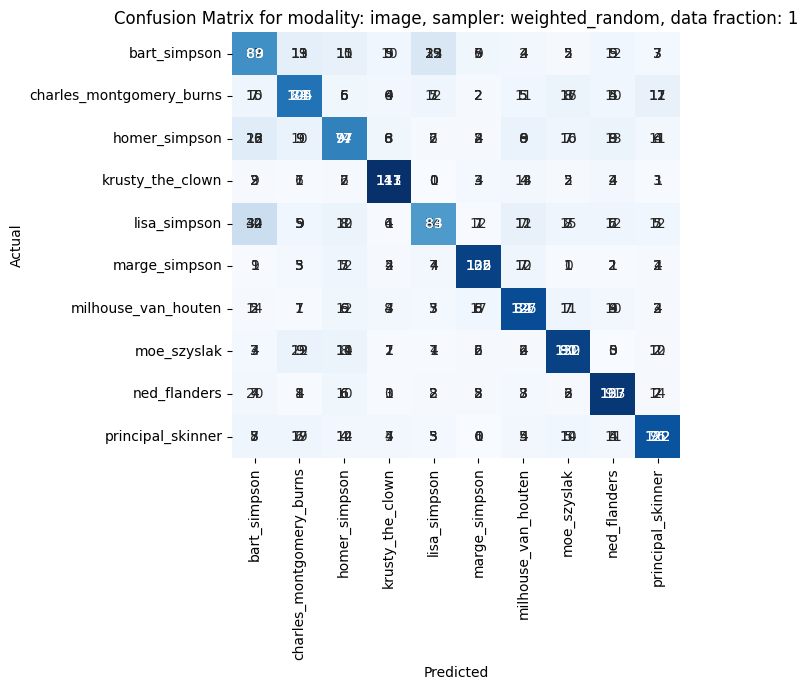

In [21]:
# Image Classifier 
for data_fraction in [0.1, 1]:
    for sampler in ["random", "weighted_random"]:
        print(f"Training Image Classifier for data fraction: {data_fraction}, sampler: {sampler}")
        image_classifier = get_image_classifier()
        model_trainer = ModelTrainer(modality="image", sampler=sampler, data_fraction=data_fraction)
        model_trainer.train_classifier(image_classifier)
        model_trainer.evaluate_classifier()
        model_trainer.save_confusion_matrix()

## Audio Classifier [2]
| Data Fraction | Sampler  | Classification Accuracy → Score                   |
| ------------- | -------- | ------------------------------------------------- |
| **10%**       | Random   | `>0.75` → 1, `0.75–0.5` → 0.5, `0.5–0.3` → 0.25, `<0.3` → 0 |
|               | Weighted | `>0.75` → 1, `0.75–0.5` → 0.5, `0.5–0.3` → 0.25, `<0.3` → 0 |
| **100%**      | Random   | `>0.8` → 1, `0.8–0.5` → 0.5, `0.5–0.3` → 0.25, `<0.3` → 0 |
|               | Weighted | `>0.8` → 1, `0.8–0.5` → 0.5, `0.5–0.3` → 0.25, `<0.3` → 0 |


In [ ]:
def get_audio_classifier():
    model = None
    ### YOUR CODE HERE
    from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier
    from sklearn.svm import SVC
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler

    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=14,
        min_samples_leaf=2,
        class_weight='balanced',
        n_jobs=-1,
        random_state=0
    )

    hgb = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=250,
        max_depth=10,
        early_stopping=True,
        random_state=0
    )

    svc = SVC(C=1.5, kernel='rbf', probability=True, random_state=0)

    ensemble = VotingClassifier(
        estimators=[('rf', rf), ('hgb', hgb), ('svc', svc)],
        voting='soft',
        weights=[1.0, 1.5, 1.0],
        n_jobs=-1
    )

    model = make_pipeline(
        StandardScaler(),
        ensemble
    )
    return model

Training Audio Classifier for data fraction: 0.1, sampler: random


/var/folders/3b/y448krm57sz31q_1j__7g2040000gn/T/ipykernel_11574/3291653124.py:409: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew(cell_flat),
/var/folders/3b/y448krm57sz31q_1j__7g2040000gn/T/ipykernel_11574/3291653124.py:410: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis(cell_flat),


Accuracy for modality: audio, sampler: random, data fraction: 0.1 is 0.5585612366230678
Training Audio Classifier for data fraction: 0.1, sampler: weighted_random


/var/folders/3b/y448krm57sz31q_1j__7g2040000gn/T/ipykernel_11574/3291653124.py:409: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew(cell_flat),
/var/folders/3b/y448krm57sz31q_1j__7g2040000gn/T/ipykernel_11574/3291653124.py:410: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis(cell_flat),


Accuracy for modality: audio, sampler: weighted_random, data fraction: 0.1 is 0.5639120095124851
Training Audio Classifier for data fraction: 1, sampler: random


/var/folders/3b/y448krm57sz31q_1j__7g2040000gn/T/ipykernel_11574/3291653124.py:409: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew(cell_flat),
/var/folders/3b/y448krm57sz31q_1j__7g2040000gn/T/ipykernel_11574/3291653124.py:410: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis(cell_flat),
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1365
  warnings.warn(


Accuracy for modality: audio, sampler: random, data fraction: 1 is 0.6810344827586207
Training Audio Classifier for data fraction: 1, sampler: weighted_random


/var/folders/3b/y448krm57sz31q_1j__7g2040000gn/T/ipykernel_11574/3291653124.py:409: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew(cell_flat),
/var/folders/3b/y448krm57sz31q_1j__7g2040000gn/T/ipykernel_11574/3291653124.py:410: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis(cell_flat),
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1365
  warnings.warn(


Accuracy for modality: audio, sampler: weighted_random, data fraction: 1 is 0.6854934601664685


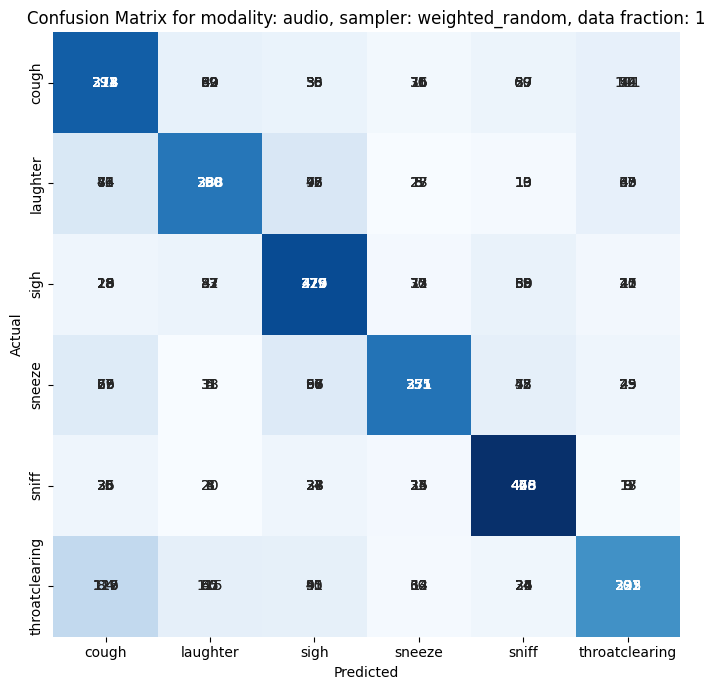

In [23]:
# Audio Classifier 
for data_fraction in [0.1, 1]:
    for sampler in ["random", "weighted_random"]:
        print(f"Training Audio Classifier for data fraction: {data_fraction}, sampler: {sampler}")
        audio_classifier = get_audio_classifier()
        model_trainer = ModelTrainer(modality="audio", sampler=sampler, data_fraction=data_fraction)
        model_trainer.train_classifier(audio_classifier)
        model_trainer.evaluate_classifier()
        model_trainer.plot_confusion_matrix()
        model_trainer.save_confusion_matrix()

## Text Classifier [2]
| Data Fraction | Sampler  | Classification Accuracy → Score                   |
| ------------- | -------- | ------------------------------------------------- |
| **10%**       | Random   | `>0.75` → 1, `0.75–0.65` → 0.5, `0.65–0.5` → 0.25, `<0.5` → 0 |
|               | Weighted | `>0.75` → 1, `0.75–0.65` → 0.5, `0.65–0.5` → 0.25, `<0.5` → 0 |
| **100%**      | Random   | `>0.8` → 1, `0.8–0.7` → 0.5, `0.7–0.5` → 0.25, `<0.5` → 0 |
|               | Weighted | `>0.9` → 1, `0.9–0.7` → 0.5, `0.7–0.5` → 0.25, `<0.5` → 0 |


In [14]:
def get_text_classifier():
    model = None
    ### YOUR CODE HERE
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import MaxAbsScaler

    model = make_pipeline(
        MaxAbsScaler(),
        LogisticRegression(
            C=5,
            solver='liblinear',
            class_weight='balanced',
            random_state=0,
            max_iter=1000,
        )
    )

    return model

Training Text Classifier for data fraction: 0.1, sampler: random


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Accuracy for modality: text, sampler: random, data fraction: 0.1 is 0.8745
Training Text Classifier for data fraction: 0.1, sampler: weighted_random


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Accuracy for modality: text, sampler: weighted_random, data fraction: 0.1 is 0.88
Training Text Classifier for data fraction: 1, sampler: random


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Accuracy for modality: text, sampler: random, data fraction: 1 is 0.9235
Training Text Classifier for data fraction: 1, sampler: weighted_random
Accuracy for modality: text, sampler: weighted_random, data fraction: 1 is 0.9235


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


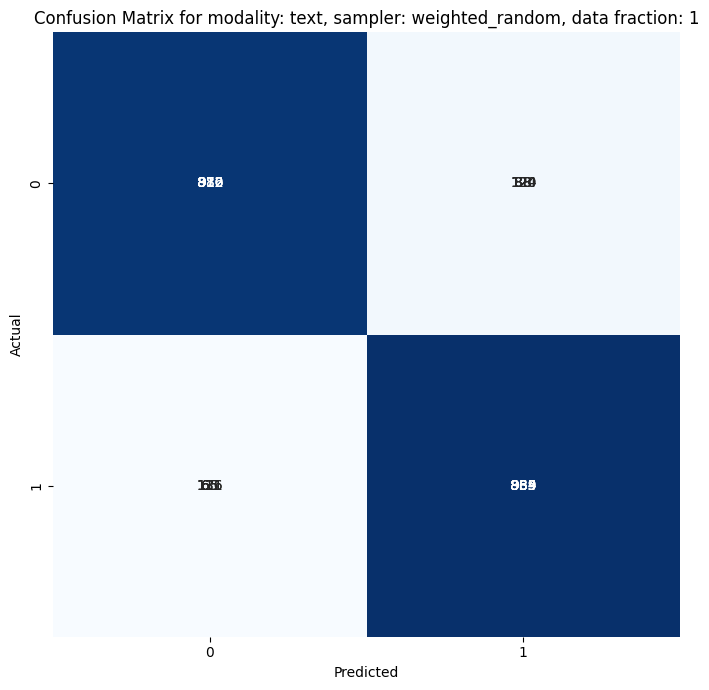

In [19]:
# Text Classifier 
for data_fraction in [0.1, 1]:
    for sampler in ["random", "weighted_random"]:
        print(f"Training Text Classifier for data fraction: {data_fraction}, sampler: {sampler}")
        text_classifier = get_text_classifier()
        model_trainer = ModelTrainer(modality="text", sampler=sampler, data_fraction=data_fraction)
        model_trainer.train_classifier(text_classifier)
        model_trainer.evaluate_classifier()
        model_trainer.plot_confusion_matrix()
        model_trainer.save_confusion_matrix()

# $${fin}$$